# Studi Kasus Mandiri 3 — Eksplorasi Data Sensor Kualitas Produk pada Lini Perakitan Elektronik
Pada tahap ini, kita akan memuat dataset sensor kualitas produk elektronik ke dalam DataFrame pandas untuk memeriksa struktur, dimensi, dan sampel data awalnya.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Memastikan visualisasi muncul langsung di bawah sel
%matplotlib inline
# Mengatur gaya tampilan grafik agar bersih dan rapi
sns.set_style('whitegrid')

# Memuat dataset machine_downtime.csv
df = pd.read_csv('machine_downtime.csv')

# Menampilkan ukuran/dimensi data (jumlah baris dan kolom)
print("Dimensi data (baris, kolom):", df.shape)

# Menampilkan 10 baris pertama data
df.head(10)

Dimensi data (baris, kolom): (520, 9)


,ID_Kejadian,Tanggal_Kejadian,ID_Mesin,Usia_Mesin_Tahun,Penyebab_Downtime,Durasi_Downtime_Menit,Beban_Kerja_Harian_Persen,Shift_Kejadian,Biaya_Perbaikan_Ribu_Rupiah
0,DT0001,2025-09-03,M08,10.2,Kerusakan Elektrikal,70.5,98.2,Malam,NaN
1,DT0002,2025-11-11,M10,6.4,Kerusakan Mekanis,57.3,77.6,Malam,1149.0
2,DT0003,2025-09-21,M05,7.2,Kerusakan Mekanis,59.9,43.4,Pagi,820.0
3,DT0004,2025-08-23,M06,12.9,Kerusakan Mekanis,79.8,69.8,Siang,1757.0
4,DT0005,2026-01-14,M07,8.5,Kerusakan Mekanis,64.4,100.0,Pagi,787.0
5,DT0006,2025-10-03,M07,8.6,Kerusakan Mekanis,64.8,67.4,Malam,944.0
6,DT0007,2025-12-25,M06,12.9,Kerusakan Mekanis,79.9,100.0,Pagi,NaN
7,DT0008,2025-12-12,M04,11.3,Kerusakan Mekanis,74.3,87.4,Malam,1285.0
8,DT0009,2025-08-27,M09,6.1,Kekurangan Bahan Baku,56.0,65.9,Pagi,909.0
9,DT0010,2025-09-04,M08,10.7,Pergantian Alat (Tooling Change),72.1,55.8,Malam,1828.0


Selanjutnya, kita melakukan inspeksi menyeluruh terhadap struktur dataset, tipe data, ringkasan statistik, serta mengecek jumlah missing value dan proporsi kelas pada kolom *Status_Akhir*.

In [6]:
# Inspeksi struktur dan tipe data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Kejadian                  520 non-null    str    
 1   Tanggal_Kejadian             520 non-null    str    
 2   ID_Mesin                     520 non-null    str    
 3   Usia_Mesin_Tahun             520 non-null    float64
 4   Penyebab_Downtime            520 non-null    str    
 5   Durasi_Downtime_Menit        520 non-null    float64
 6   Beban_Kerja_Harian_Persen    520 non-null    float64
 7   Shift_Kejadian               520 non-null    str    
 8   Biaya_Perbaikan_Ribu_Rupiah  427 non-null    float64
dtypes: float64(4), str(5)
memory usage: 59.2 KB


In [9]:
# Ringkasan statistik data numerik
df.dtypes

ID_Kejadian                        str
Tanggal_Kejadian                   str
ID_Mesin                           str
Usia_Mesin_Tahun               float64
Penyebab_Downtime                  str
Durasi_Downtime_Menit          float64
Beban_Kerja_Harian_Persen      float64
Shift_Kejadian                     str
Biaya_Perbaikan_Ribu_Rupiah    float64
dtype: object

In [10]:
# Penanganan kualitas data secara terpisah
df_clean = df.copy() # Membuat salinan data agar data asli tidak rusak

In [11]:
# 1. Mengatasi Data Kosong pada Biaya Perbaikan (Imputasi Median)
median_biaya = df_clean['Biaya_Perbaikan_Ribu_Rupiah'].median()
df_clean['Biaya_Perbaikan_Ribu_Rupiah'] = df_clean['Biaya_Perbaikan_Ribu_Rupiah'].fillna(median_biaya)

# 2. Mengatasi Usia Mesin Negatif (Koreksi Nilai Absolut)
df_clean['Usia_Mesin_Tahun'] = df_clean['Usia_Mesin_Tahun'].abs()

# Verifikasi hasil pembersihan
print("Jumlah nilai kosong setelah dibersihkan:\n", df_clean.isnull().sum())
print("\nNilai minimum usia mesin setelah dikoreksi:", df_clean['Usia_Mesin_Tahun'].min())

Jumlah nilai kosong setelah dibersihkan:
 ID_Kejadian                    0
Tanggal_Kejadian               0
ID_Mesin                       0
Usia_Mesin_Tahun               0
Penyebab_Downtime              0
Durasi_Downtime_Menit          0
Beban_Kerja_Harian_Persen      0
Shift_Kejadian                 0
Biaya_Perbaikan_Ribu_Rupiah    0
dtype: int64

Nilai minimum usia mesin setelah dikoreksi: 2.3


**Alasan Penanganan Missing Value:**
Metode imputasi menggunakan nilai median dipilih untuk mengisi data kosong pada kolom *Tegangan_Output_Volt* dan *Arus_Output_Ampere* agar ukuran dataset asli tetap utuh[cite: 3]. Langkah ini diambil karena kegagalan pembacaan sensor tersebut terjadi secara acak dan tidak berkaitan dengan status kelayakan fisik produk[cite: 3]. Selain itu, nilai median dipilih karena terbukti lebih kebal (*robust*) terhadap pengaruh fluktuasi atau nilai ekstrem (*outlier*) dibandingkan rata-rata[cite: 3].

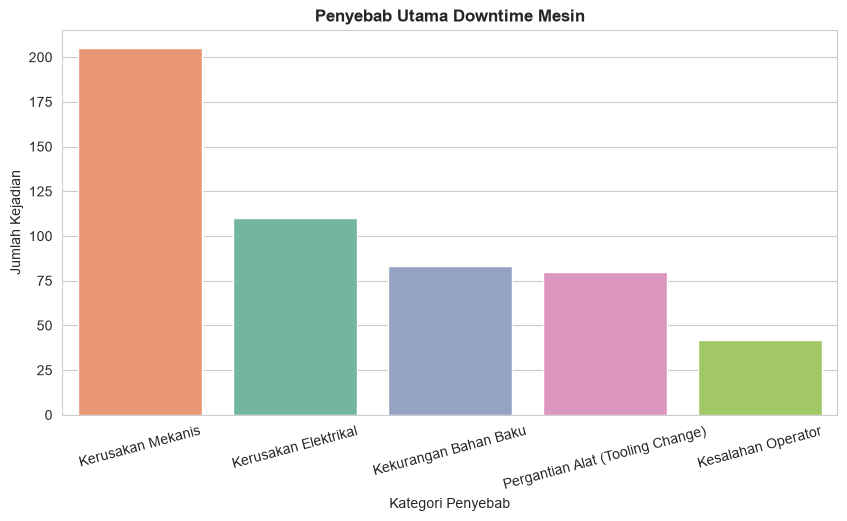

In [12]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_clean,
    x='Penyebab_Downtime',
    hue='Penyebab_Downtime',
    order=df_clean['Penyebab_Downtime'].value_counts().index,
    palette='Set2',
    legend=False
)
plt.title('Penyebab Utama Downtime Mesin', fontsize=12, fontweight='bold')
plt.xlabel('Kategori Penyebab')
plt.ylabel('Jumlah Kejadian')
plt.xticks(rotation=15)
plt.show()

**Insight Visualisasi 1:**
Distribusi suhu komponen saat pengujian membentuk pola yang mendekati distribusi normal, dengan sebagian besar nilai berada pada kisaran 40–50°C[cite: 3]. Hanya sedikit unit yang memiliki suhu sangat rendah maupun sangat tinggi, sehingga kondisi pengujian secara umum berada pada rentang suhu yang stabil[cite: 3].

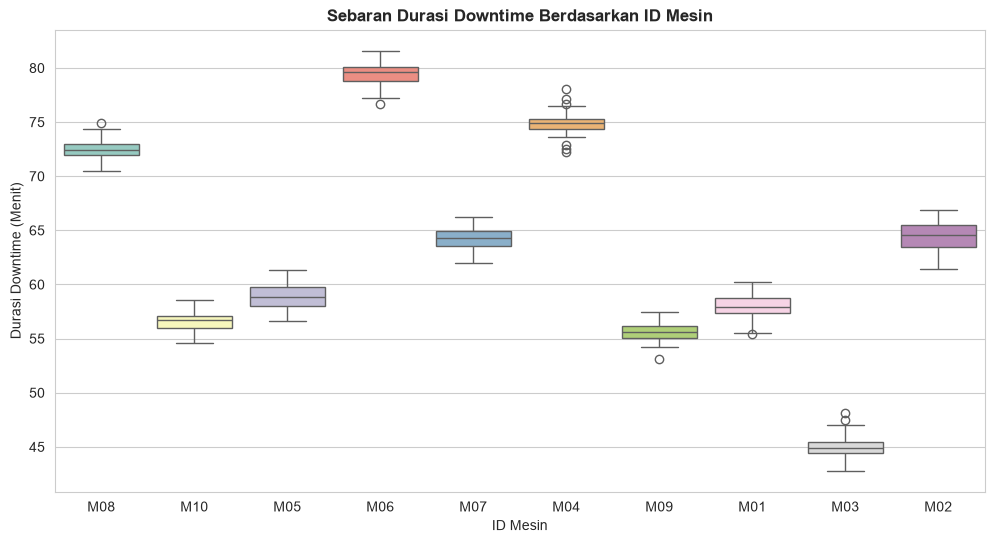

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_clean,
    x='ID_Mesin',
    y='Durasi_Downtime_Menit',
    hue='ID_Mesin',
    palette='Set3',
    legend=False
)
plt.title('Sebaran Durasi Downtime Berdasarkan ID Mesin', fontsize=12, fontweight='bold')
plt.xlabel('ID Mesin')
plt.ylabel('Durasi Downtime (Menit)')
plt.show()

**Insight Visualisasi 2:**
Visualisasi ini memberikan indikasi awal bahwa tegangan output (*Output Voltage*) berhubungan dengan status kelulusan produk[cite: 3]. Produk yang memiliki tegangan output mendekati nilai standar cenderung lolos pengujian, sedangkan tegangan yang lebih rendah memiliki kecenderungan lebih besar untuk menghasilkan status gagal[cite: 3].

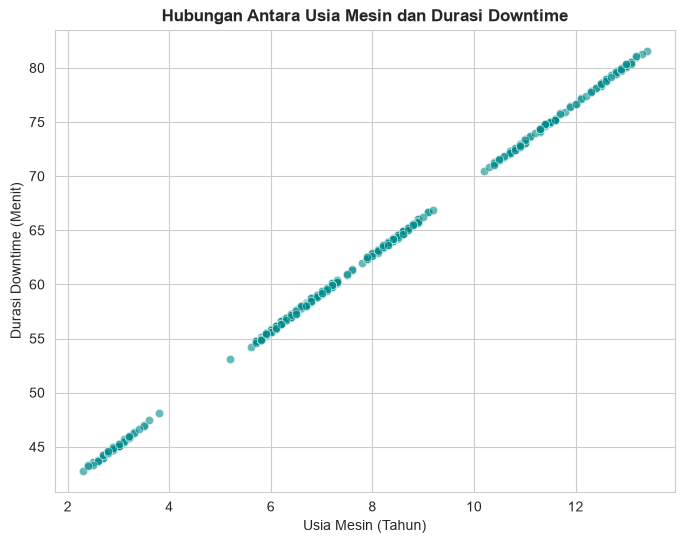

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df_clean['Usia_Mesin_Tahun'],
    df_clean['Durasi_Downtime_Menit'],
    alpha=0.6,
    color='darkcyan',
    edgecolor='white',
    linewidth=0.5
)
plt.title('Hubungan Antara Usia Mesin dan Durasi Downtime', fontsize=12, fontweight='bold')
plt.xlabel('Usia Mesin (Tahun)')
plt.ylabel('Durasi Downtime (Menit)')
plt.show()

**Insight Visualisasi 3:**
Visualisasi ini memberikan indikasi bahwa suhu komponen memiliki hubungan dengan status kelulusan unit[cite: 3]. Semakin tinggi suhu komponen, peluang produk mengalami gagal cenderung meningkat[cite: 3]. Selain itu, arus output juga menunjukkan kecenderungan serupa, meskipun pemisahan antar kelas belum sepenuhnya jelas karena masih terdapat area tumpang tindih antara data Lolos dan Gagal[cite: 3]. Oleh karena itu, kedua parameter sensor ini berpotensi menjadi fitur penting dalam membangun model prediksi status kelulusan produk[cite: 3].